<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [156]:
#Importation de la librairie Pandas
import pandas as pd

In [157]:
#Importation de la librairie plotly express
import plotly.express as px

In [158]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [159]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [160]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [161]:
#Consulter le nombre de colonnes
df_erp.shape[1]
#La nature des données dans chacune des colonnes
df_erp.dtypes
#Le nombre de valeurs présentes dans chacune des colonnes
# Afficher les informations générales sur le dataframe (type des colonnes, nb de valeurs non nulles, etc.)
df_erp.info()

# Compter le nombre de valeurs non nulles par colonne
df_erp.count()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64

In [162]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [163]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp["product_id"].duplicated().sum()

np.int64(0)

In [164]:
#Afficher les valeurs distinctes de la colonne stock_status
df_erp["stock_status"].unique()
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
# Vérifier la cohérence entre le statut et la quantité réelle
df_erp[["product_id", "stock_status", "stock_quantity"]].head()

,product_id,stock_status,stock_quantity
0,3847,instock,16
1,3849,instock,10
2,3850,outofstock,0
3,4032,instock,26
4,4039,outofstock,3


In [165]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"

# Utilisation de la méthode .apply avec une fonction lambda (pur Pandas)
df_erp["stock_status_2"] = df_erp["stock_quantity"].apply(lambda x: "outofstock" if x <= 0 else "instock")

In [166]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [167]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

np.int64(823)

In [168]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

In [169]:
#Corriger la ou les données incohérentes
#On applique la règle logique à la colonne d'origine pour corriger les erreurs détectées
df_erp["stock_status"] = df_erp["stock_quantity"].apply(
    lambda x: "outofstock" if (pd.isna(x) or x <= 0) else "instock"
)

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
#On cherche à nouveau les lignes où le statut est 'outofstock' mais la quantité > 0
incoherences = df_erp[
    (df_erp['stock_status'] == 'outofstock') & (df_erp['stock_quantity'] > 0)
]

print("--- Nombre de lignes incohérentes après correction ---")
print(len(incoherences))

--- Nombre de lignes incohérentes après correction ---
0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [170]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
#On utilise .isna() pour compter les valeurs manquantes
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp["price"].isna().sum())) 

#Afficher le prix minimum de la colonne "price"
print("Prix minimum :", df_erp["price"].min())

#Afficher le prix maximum de la colonne "price"
print("Prix maximum :", df_erp["price"].max())

#Afficher les prix inférieurs ou égaux à 0 (qu'est-ce qu'il faut en faire ?)
#On filtre le DataFrame pour isoler ces anomalies
prix_anormaux = df_erp[df_erp["price"] <= 0]
print("\nArticles avec un prix nul ou négatif :")
print(prix_anormaux[["product_id", "price"]])


Nombres d'articles avec un prix non renseigné: 0
Prix minimum : -20.0
Prix maximum : 225.0

Articles avec un prix nul ou négatif :
     product_id  price
151        4233  -20.0
469        5017   -8.0
739        6594   -9.1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [171]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum :", df_erp["stock_quantity"].min())

#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum :", df_erp["stock_quantity"].max())

#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
stocks_negatifs = df_erp[df_erp["stock_quantity"] < 0]
print("\nArticles avec un stock négatif :")
print(stocks_negatifs[["product_id", "stock_quantity"]])



Quantité minimum : -10
Quantité maximum : 145

Articles avec un stock négatif :
     product_id  stock_quantity
449        4973             -10
573        5700              -1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [172]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp["onsale_web"].value_counts() 

onsale_web
1    716
0    109
Name: count, dtype: int64

In [173]:
#Quelles sont les colonnes à conserver selon vous?
#Quelles sont les colonnes à conserver selon vous?
# Colonnes conservées car utiles pour l’analyse métier et les croisements de données :
# - product_id : identifiant unique du produit
# - onsale_web : indique si le produit est vendu sur le site web
# - price : prix de vente
# - purchase_price : prix d'achat, utile pour le calcul de la marge
# - stock_quantity : quantité disponible en stock
# - stock_status : statut du stock (instock / outofstock)

In [174]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns="stock_status_2", inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [175]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix d'achat non renseigné : {}".format(df_erp["purchase_price"].isna().sum()))

#Afficher le prix minimum de la colonne "purchase_price"
print("Prix d'achat minimum :", df_erp["purchase_price"].min())

#Afficher le prix maximum de la colonne "purchase_price"
print("Prix d'achat maximum :", df_erp["purchase_price"].max())


Nombres d'articles avec un prix d'achat non renseigné : 0
Prix d'achat minimum : 2.74
Prix d'achat maximum : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [176]:
#Dimension du dataset
df_web.shape
#Nombre d'observations
print("Nombre d'observations :", df_web.shape[0])
#Nombre de caractéristiques
print("Nombre de caractéristiques :", df_web.shape[1])
df_web.shape

Nombre d'observations : 1513
Nombre de caractéristiques : 29


(1513, 29)

In [177]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [178]:
#Selon vous, quelles sont les colonnes à conserver ?
# Sélection des colonnes stratégiques
colonnes_utiles = ['sku', 'total_sales', 'post_title', 'post_type', 'post_status']

# Création du DataFrame filtré
df_web_select = df_web[colonnes_utiles]

# Aperçu du nouveau DataFrame
df_web_select.head()

,sku,total_sales,post_title,post_type,post_status
0,11862,3.0,Gilles Robin Hermitage Rouge 2012,attachment,publish
1,16057,5.0,Domaine Pellé Sancerre Rouge La Croix Au Garde...,attachment,publish
2,14692,5.0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product,publish
3,16295,14.0,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,attachment,publish
4,15328,2.0,Agnès Levet Côte Rôtie Maestria 2017,product,publish


In [179]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web[['sku', 'total_sales', 'post_title', 'post_type', 'post_status']]

# Vérification du résultat
df_web.head()

,sku,total_sales,post_title,post_type,post_status
0,11862,3.0,Gilles Robin Hermitage Rouge 2012,attachment,publish
1,16057,5.0,Domaine Pellé Sancerre Rouge La Croix Au Garde...,attachment,publish
2,14692,5.0,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product,publish
3,16295,14.0,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,attachment,publish
4,15328,2.0,Agnès Levet Côte Rôtie Maestria 2017,product,publish


In [180]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
#Visualisation des valeurs de la colonne sku
#On affiche les valeurs uniques pour repérer les anomalies visuellement
print(df_web['sku'].unique())

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
#On cherche les valeurs non-numériques, les formats trop courts/longs ou les valeurs manquantes
sku_atypiques = df_web[df_web['sku'].isna() | df_web['sku'].str.contains(r'\D', na=False)]
print("\nValeurs ne respectant pas la codification habituelle :")
print(sku_atypiques['sku'].unique())

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

In [181]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
# On affiche simplement les lignes où le SKU est manquant (NaN)
df_web[df_web['sku'].isna()]

,sku,total_sales,post_title,post_type,post_status
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [182]:
#Identifier les lignes sans code article
# On affiche les lignes où la colonne 'sku' est vide
df_web[df_web['sku'].isna()]

,sku,total_sales,post_title,post_type,post_status
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [183]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre

# Analyse : On regarde ce que contiennent ces lignes sans SKU (titre, ventes, etc.)
print("Détail des lignes sans SKU :")
display(df_web[df_web['sku'].isna()])

# Action : 
# 1. Si les lignes sont totalement vides (que des NaN) -> Suppression.
# 2. Si elles contiennent des titres mais pas de SKU -> Investigation (doublon technique ?).
# 3. Pour le moment, on peut les mettre de côté dans un DataFrame "df_orphelins" au lieu de les supprimer.

Détail des lignes sans SKU :


,sku,total_sales,post_title,post_type,post_status
8,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN
1429,NaN,NaN,NaN,NaN,NaN
1432,NaN,NaN,NaN,NaN,NaN
1445,NaN,NaN,NaN,NaN,NaN


In [184]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
# Analyse : On compte combien de lignes sont concernées
print("Nombre de lignes sans SKU :", df_web['sku'].isna().sum())

# Action : Comme on ne peut pas lier ces produits à l'ERP sans SKU, 
# on décide de ne pas les inclure pour la suite de l'analyse.
df_web = df_web.dropna(subset=['sku'])

Nombre de lignes sans SKU : 85


In [185]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
# 1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_sku = df_web[df_web['sku'].isna()]

# 2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sans_sku.info() 

#3 - Que constatez-vous?

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          0 non-null      object 
 1   total_sales  0 non-null      float64
 2   post_title   0 non-null      object 
 3   post_type    0 non-null      object 
 4   post_status  0 non-null      object 
dtypes: float64(1), object(4)
memory usage: 0.0+ bytes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [186]:
# Dimension du dataset
print(df_liaison.shape)

# Nombre d'observations
print(len(df_liaison))

# Nombre de caractéristiques
print(df_liaison.shape[1])

(825, 2)
825
2


In [187]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [188]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print(df_liaison['product_id'].is_unique)

True


In [189]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(df_liaison['id_web'].is_unique)

False


In [190]:
#Avons-nous des articles sans correspondance?
articles_sans_correspondance = df_liaison['id_web'].isna().sum()
print(f"Il y a {articles_sans_correspondance} articles sans id_web.")

# Pour voir les lignes concernées :
df_liaison[df_liaison['id_web'].isna()]

Il y a 91 articles sans id_web.


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [191]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, on='product_id', how='outer', indicator=True)
# Vérification du résultat
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both


In [192]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
# On affiche les lignes qui ne sont pas présentes dans les deux fichiers à la fois
df_merge[df_merge['_merge'] != 'both']

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [193]:
#Fusionner les datasets df_merge et df_web
df_final = pd.merge(df_merge, df_web, left_on='id_web', right_on='sku', how='outer')

# Aperçu du résultat final
df_final.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,post_title,post_type,post_status
0,4729,1,8.6,26,instock,4.22,38,both,38,10.0,Emile Boeckel Crémant Brut Blanc de Blancs,attachment,publish
1,4729,1,8.6,26,instock,4.22,38,both,38,10.0,Emile Boeckel Crémant Brut Blanc de Blancs,product,publish
2,4634,1,41.0,11,instock,20.12,41,both,41,6.0,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product,publish
3,4634,1,41.0,11,instock,20.12,41,both,41,6.0,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,attachment,publish
4,4141,1,39.0,123,instock,24.86,304,both,304,8.0,Champagne Gosset Grande Réserve,attachment,publish


In [194]:
#Avons-nous des lignes sans correspondance?

# On cherche les lignes où l'id_web (venant de l'ERP) ou le sku (venant du Web) est vide
non_match = df_final[df_final['id_web'].isna() | df_final['sku'].isna()]

print(f"Nombre de lignes sans correspondance : {len(non_match)}")
display(non_match)

Nombre de lignes sans correspondance : 111


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,post_title,post_type,post_status
162,4741,0,12.4,0,outofstock,6.66,12601,both,NaN,NaN,NaN,NaN,NaN
253,5957,0,39.0,0,outofstock,20.75,13577,both,NaN,NaN,NaN,NaN,NaN
276,4289,0,22.8,0,outofstock,11.90,13771,both,NaN,NaN,NaN,NaN,NaN
357,4869,0,17.2,0,outofstock,9.33,14360,both,NaN,NaN,NaN,NaN,NaN
366,5955,0,27.3,0,outofstock,13.68,14377,both,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1534,7196,0,31.0,55,instock,31.20,NaN,both,NaN,NaN,NaN,NaN,NaN
1535,7200,0,31.0,6,instock,15.54,NaN,both,NaN,NaN,NaN,NaN,NaN
1536,7201,0,31.0,18,instock,16.02,NaN,both,NaN,NaN,NaN,NaN,NaN
1537,7203,0,45.0,30,instock,23.48,NaN,both,NaN,NaN,NaN,NaN,NaN


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

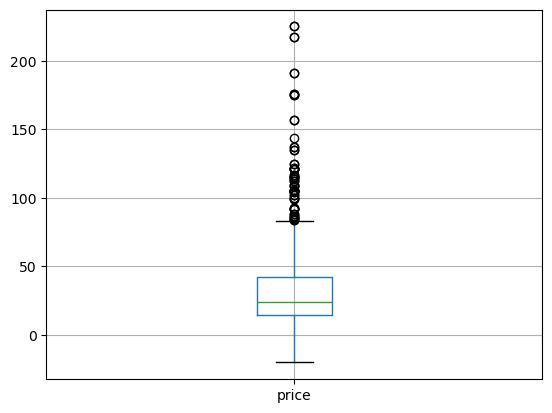

In [195]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
# Génération du graphique via Pandas
import matplotlib.pyplot as plt
df_final.boxplot(column='price')

# Affichage propre
plt.show()

In [196]:
#Autre méthode avec plotly express
fig = px.box(df_final, y="price", title="Répartition des prix des produits")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [197]:
# Calculer la moyenne du prix
mean_price = df_final["price"].mean()

# Calculer l'écart-type du prix
std_price = df_final["price"].std()

# Calculer le Z-score
# La formule est : (prix - moyenne) / écart-type
df_final['z_score'] = (df_final['price'] - mean_price) / std_price

# Afficher les premières lignes pour vérifier
display(df_final[['price', 'z_score']].head())

,price,z_score
0,8.6,-0.872342
1,8.6,-0.872342
2,41.0,0.322474
3,41.0,0.322474
4,39.0,0.248720


In [198]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
# Formule : Seuil = Moyenne + (3 * Écart-type)
seuil_zscore_3 = mean_price + (3 * std_price)

print(f"Le seuil de prix pour un Z-score > 3 est de : {seuil_zscore_3:.2f} €")

Le seuil de prix pour un Z-score > 3 est de : 113.61 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [199]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_final['price'].describe()

count    1539.000000
mean       32.255426
std        27.117137
min       -20.000000
25%        14.300000
50%        24.000000
75%        42.000000
max       225.000000
Name: price, dtype: float64

In [200]:
# Définir un seuil pour les articles "outliers" en prix

# 1. Calculer Q1 (25%) et Q3 (75%)
# (On travaille sur une version propre : 1 ligne par SKU + suppression des NaN)
df_price = df_final.drop_duplicates(subset=['sku']).copy()
s_price = df_price["price"].dropna()

Q1 = s_price.quantile(0.25)
Q3 = s_price.quantile(0.75)

# 2. Calculer l’écart interquartile (IQR)
IQR = Q3 - Q1

# 3. Définir le seuil haut (Outliers supérieurs)
# La règle standard est : Q3 + 1.5 * IQR
seuil_outlier = Q3 + (1.5 * IQR)

print(f"Le seuil pour les articles 'outliers' est de : {seuil_outlier:.2f} €")

Le seuil pour les articles 'outliers' est de : 84.09 €


In [201]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
# 1. On définit d'abord ce qu'est df_outliers (les prix > au seuil)
df_outliers = df_price[df_price['price'] > seuil_outlier].copy()

# 2. Définir le nombre d'articles
nb_outliers = len(df_outliers)

# 3. Définir la proportion de l'ensemble du catalogue
proportion_outliers = nb_outliers / len(df_price)

# Affichage des résultats
print(f"Nombre d'articles outliers : {nb_outliers}")
print(f"Proportion dans le catalogue : {proportion_outliers:.2%}")

Nombre d'articles outliers : 31
Proportion dans le catalogue : 4.34%


In [202]:
# Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
# CODE POUR DÉMONTRER LA JUSTIFICATION

# Afficher les 10 plus gros prix : on y verra des vins de prestige
# (On utilise df_outliers issu de df_price : 1 ligne = 1 produit, donc pas de doublons)
display(df_outliers[['post_title', 'price', 'total_sales']].sort_values(by='price', ascending=False).head(10))

# Calculer le CA généré par ces "outliers" pour prouver leur valeur business
# (On sécurise total_sales : NaN -> 0 pour éviter que le CA devienne NaN)
df_outliers['total_sales'] = df_outliers['total_sales'].fillna(0)

ca_outliers = (df_outliers['price'] * df_outliers['total_sales']).sum()
print(f"\nCA total généré par les outliers : {ca_outliers:.2f} €")

# Conclusion : ces valeurs "atypiques" ne sont pas forcément des erreurs de saisie.
# Elles peuvent s'expliquer par des produits de prestige (rareté, appellation, millésime, Grands Crus),
# dont le prix est naturellement plus élevé que le reste du catalogue.

,post_title,price,total_sales
1115,Champagne Egly-Ouriet Grand Cru Millésimé 2008,225.0,11.0
402,David Duband Charmes-Chambertin Grand Cru 2014,217.5,2.0
527,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,191.3,6.0
48,Cognac Frapin VIP XO,176.0,3.0
613,Camille Giroud Clos de Vougeot 2016,175.0,4.0
66,Cognac Frapin Château de Fontpinot 1989 20 Ans...,157.0,4.0
339,Domaine Des Croix Corton Charlemagne Grand Cru...,137.0,3.0
503,Champagne Gosset Célébris Vintage 2007,135.0,5.0
501,Domaine Weinbach Gewurztraminer Grand Cru Furs...,124.8,1.0
460,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,122.0,3.0



CA total généré par les outliers : 16609.80 €


In [203]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539 entries, 0 to 1538
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   product_id      1539 non-null   int64   
 1   onsale_web      1539 non-null   int64   
 2   price           1539 non-null   float64 
 3   stock_quantity  1539 non-null   int64   
 4   stock_status    1539 non-null   object  
 5   purchase_price  1539 non-null   float64 
 6   id_web          1448 non-null   object  
 7   _merge          1539 non-null   category
 8   sku             1428 non-null   object  
 9   total_sales     1428 non-null   float64 
 10  post_title      1428 non-null   object  
 11  post_type       1428 non-null   object  
 12  post_status     1428 non-null   object  
 13  z_score         1539 non-null   float64 
dtypes: category(1), float64(4), int64(3), object(6)
memory usage: 158.1+ KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [204]:
# Nettoyage des doublons pour ne garder qu'une ligne par produit
df_ca = df_final.drop_duplicates(subset=['sku']).copy()

# Sécurisation minimale : éviter des NaN qui bloquent le calcul
df_ca['price'] = df_ca['price'].fillna(0)
df_ca['total_sales'] = df_ca['total_sales'].fillna(0)

# Calcul CA
df_ca['ca_par_article'] = df_ca['price'] * df_ca['total_sales']
ca_total = df_ca['ca_par_article'].sum()
nombre_produits = len(df_ca)

print(f"Nombre de produits après nettoyage : {nombre_produits}")
print(f"CA total corrigé : {ca_total:,.2f} €")

Nombre de produits après nettoyage : 715
CA total corrigé : 153,748.10 €


In [205]:
##############################
# Calculer le CA du site web # 
##############################

# (Re)calcul de sécurité au cas où ce bloc est relancé seul
df_ca['price'] = df_ca['price'].fillna(0)
df_ca['total_sales'] = df_ca['total_sales'].fillna(0)
df_ca['ca_par_article'] = df_ca['price'] * df_ca['total_sales']

nombre_produits = len(df_ca)
ca_total = df_ca['ca_par_article'].sum()

print(f"Nombre de produits analysés : {nombre_produits}")
print(f"Le Chiffre d'Affaires total réalisé sur le site web est de : {ca_total:,.2f} €")


Nombre de produits analysés : 715
Le Chiffre d'Affaires total réalisé sur le site web est de : 153,748.10 €


In [206]:
###############################
# Palmarès des articles en CA #
###############################

# 1. Effectuer le tri dans l'ordre décroissant du CA du dataset
# On utilise la colonne 'ca_par_article' créée précédemment
df_palmares = df_ca.sort_values(by='ca_par_article', ascending=False)

# 2. Réinitialiser l'index du dataset par un reset_index
# drop=True évite de créer une colonne avec l'ancien index
df_palmares = df_palmares.reset_index(drop=True)

# 3. Afficher les 20 premiers articles en CA
print("Top 20 des articles par Chiffre d'Affaires :")
display(df_palmares[['post_title', 'ca_par_article']].head(20))

Top 20 des articles par Chiffre d'Affaires :


,post_title,ca_par_article
0,Champagne Mailly Grand Cru Intemporelle 2010,6844.0
1,Champagne Egly-Ouriet Grand Cru Millésimé 2008,2475.0
2,François Baur Pinot Noir Schlittweg 2017,1549.4
3,Albert Mann Pinot Noir Grand H 2017,1317.8
4,Argentine Mendoza Alamos Torrontes 2017,1232.1
5,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,1147.8
6,Champagne Egly-Ouriet Grand Cru Brut Rosé,1113.0
7,Agnès Levet Côte Rôtie Améthyste 2017,824.0
8,Domaine des Comtes Lafon Volnay 1er Cru Santen...,805.0
9,Champagne Agrapart &amp; Fils Minéral Extra Br...,781.2


In [207]:
# 4. Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px

fig = px.bar(
    df_palmares.head(20),
    x='ca_par_article',
    y='post_title',
    orientation='h',
    title='Top 20 des articles générant le plus de CA',
    labels={
        'ca_par_article': "Chiffre d'Affaires (€)",
        'post_title': 'Nom du Vin'
    },
    color='ca_par_article',
    color_continuous_scale='Reds'
)

# Inverser l'axe Y pour avoir le 1er en haut
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [208]:
#############################
# Calculer le 20 / 80 en CA #
#############################

# 1. Créer une colonne calculant la part du CA de la ligne dans le dataset
# On divise le CA de chaque article par le CA total
df_palmares['part_ca'] = df_palmares['ca_par_article'] / ca_total

# 2. Créer une colonne réalisant la somme cumulative de la part du CA
# On utilise .cumsum() pour additionner les parts au fur et à mesure
df_palmares['ca_cumule'] = df_palmares['part_ca'].cumsum()

# 3. Calculer le nombre d'articles représentant 80% du CA
# On prend le nombre minimal d'articles nécessaires pour atteindre au moins 80%
nb_articles_80_ca = (df_palmares['ca_cumule'] < 0.80).sum() + 1

# 4. Afficher la proportion que représente ce groupe d'articles dans le catalogue entier
proportion_pareto = nb_articles_80_ca / len(df_palmares)

print(f"Nombre d'articles générant 80% du CA : {nb_articles_80_ca}")
print(f"Proportion du catalogue : {proportion_pareto:.2%}")

Nombre d'articles générant 80% du CA : 421
Proportion du catalogue : 58.88%


In [209]:
df_palmares.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,post_title,post_type,post_status,z_score,ca_par_article,part_ca,ca_cumule
0,4150,1,59.0,123,instock,35.45,1366,both,1366,116.0,Champagne Mailly Grand Cru Intemporelle 2010,attachment,publish,0.986261,6844.0,0.044514,0.044514
1,4352,1,225.0,0,outofstock,137.81,15940,both,15940,11.0,Champagne Egly-Ouriet Grand Cru Millésimé 2008,attachment,publish,7.107851,2475.0,0.016098,0.060612
2,4726,1,12.7,0,outofstock,6.82,14950,both,14950,122.0,François Baur Pinot Noir Schlittweg 2017,attachment,publish,-0.721146,1549.4,0.010078,0.070690
3,5067,1,59.9,3,instock,30.95,15346,both,15346,22.0,Albert Mann Pinot Noir Grand H 2017,attachment,publish,1.019450,1317.8,0.008571,0.079261
4,5379,1,11.1,33,instock,5.68,14561,both,14561,111.0,Argentine Mendoza Alamos Torrontes 2017,attachment,publish,-0.780150,1232.1,0.008014,0.087275


In [210]:
#Calculer le pourcentage cumulatif
df_palmares['ca_cumule_%'] = df_palmares['ca_cumule']  # proportion entre 0 et 1

In [211]:
#Nombre des références dans 20 / 80 en CA
nb_refs_80 = (df_palmares["ca_cumule_%"] < 0.8).sum() + 1
print(f"Nombre de réf représentant 80% du CA : {nb_refs_80} articles")

#Proportion du catalogue
proportion_catalogue = round(nb_refs_80 / df_palmares.shape[0] * 100, 2)
print(f"Cela correspond à {proportion_catalogue}% du catalogue")

Nombre de réf représentant 80% du CA : 421 articles
Cela correspond à 58.88% du catalogue


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [212]:
##############################
# Palmarès des articles en quantité #
##############################

# 0. Nettoyage des doublons pour ne garder qu'une ligne par produit
# IMPORTANT : on ne modifie pas df_final (utilisé dans la suite)
df_qte = df_final.drop_duplicates(subset=['sku']).copy()

# Sécurisation : éviter les NaN dans total_sales
df_qte['total_sales'] = df_qte['total_sales'].fillna(0)

# 1. Effectuer le tri dans l'ordre décroissant de quantité vendue du dataset
df_quantite = df_qte.sort_values(by='total_sales', ascending=False)

# 2. Réinitialiser l'index du dataset par un reset_index
df_quantite = df_quantite.reset_index(drop=True)

# 3. Afficher les 20 premiers articles les plus vendus en quantité
print("Top 20 des articles les plus vendus (quantité) :")
display(df_quantite[['post_title', 'total_sales']].head(20))

Top 20 des articles les plus vendus (quantité) :


,post_title,total_sales
0,François Baur Pinot Noir Schlittweg 2017,122.0
1,Champagne Mailly Grand Cru Intemporelle 2010,116.0
2,Argentine Mendoza Alamos Torrontes 2017,111.0
3,Château De La Selve IGP Coteaux de l'Ardèche M...,36.0
4,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,27.0
5,I Fabbri Chianti Classico Lamole 2017,24.0
6,Albert Mann Pinot Noir Grand H 2017,22.0
7,Bernard Baudry Chinon Rouge La Croix Boissée 2017,22.0
8,Agnès Levet Côte Rôtie Améthyste 2017,20.0
9,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,20.0


In [213]:
# 4. Graphique en barre des 20 premiers articles avec plotly express
import plotly.express as px

fig_qty = px.bar(df_quantite.head(20), 
                 x='total_sales', 
                 y='post_title', 
                 orientation='h',
                 title='Top 20 des meilleures ventes en volume',
                 labels={'total_sales':'Quantité vendue', 'post_title':'Nom du Vin'},
                 color='total_sales',
                 color_continuous_scale='Blues') # Bleu pour différencier du CA (souvent en rouge)

# Inverser l'axe Y pour la lecture
fig_qty.update_layout(yaxis={'categoryorder':'total ascending'})
fig_qty.show()


In [214]:
#############################
# Calculer le 20 / 80 en quantité #
#############################

# 1. Créer une colonne calculant la part en quantité de la ligne dans le dataset
total_ventes_quantite = df_quantite['total_sales'].sum()
df_quantite['part_quantite'] = df_quantite['total_sales'] / total_ventes_quantite

# 2. Créer une colonne réalisant la somme cumulative de la part en quantité
df_quantite['qty_cumule'] = df_quantite['part_quantite'].cumsum()

# 3. Calculer le nombre d'articles représentant 80% des ventes en quantité
# On prend le nombre minimal d'articles nécessaires pour atteindre au moins 80%
nb_articles_80_qty = (df_quantite['qty_cumule'] < 0.80).sum() + 1

# 4. Afficher la proportion que représente ce groupe d'articles dans le catalogue entier
proportion_pareto_qty = nb_articles_80_qty / len(df_quantite)

print(f"Nombre d'articles générant 80% des ventes (quantité) : {nb_articles_80_qty}")
print(f"Proportion du catalogue : {proportion_pareto_qty:.2%}")


Nombre d'articles générant 80% des ventes (quantité) : 425
Proportion du catalogue : 59.44%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [215]:
######################################
# Calculer le nombre de mois de stock #
######################################

# 0) Import des librairies nécessaires
import numpy as np

# 1) Créer un dataframe dédié
df_stock = df_final.copy()

# 2) Nettoyer total_sales (NaN -> 0)
df_stock['total_sales'] = df_stock['total_sales'].fillna(0)

# 3) Supprimer les doublons : 1 ligne par produit (SKU)
# On évite de "doubler" les valeurs en prenant max (doublons = copies)
# IMPORTANT : on conserve aussi le prix d'achat pour pouvoir valoriser le stock
df_stock = (
    df_stock
    .groupby(['sku', 'post_title'], as_index=False)
    .agg({
        'stock_quantity': 'max',
        'total_sales': 'max',
        'purchase_price': 'max'
    })
)

# 4) Calcul de la rotation (octobre = 1 mois)
df_stock['rotation_stock'] = (
    df_stock['stock_quantity'] /
    df_stock['total_sales'].replace(0, np.nan)
)

# Cas métier : stock > 0 et ventes = 0 => stock bloqué
df_stock.loc[
    (df_stock['total_sales'] == 0) & (df_stock['stock_quantity'] > 0),
    'rotation_stock'
] = np.inf

df_stock.loc[
    (df_stock['total_sales'] == 0) & (df_stock['stock_quantity'] == 0),
    'rotation_stock'
] = 0

# Tri décroissant
df_flop_stock = df_stock.sort_values(by='rotation_stock', ascending=False)

# Vérification rapide (optionnel)
print("SKU dupliqués dans df_stock :", df_stock['sku'].duplicated().sum())
df_stock[['post_title','stock_quantity','total_sales','rotation_stock']].head(30)

SKU dupliqués dans df_stock : 0


,post_title,stock_quantity,total_sales,rotation_stock
0,Emile Boeckel Crémant Brut Blanc de Blancs,26,10.0,2.600000
1,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,11,6.0,1.833333
2,Champagne Gosset Grande Réserve,123,8.0,15.375000
3,Cognac Normandin Mercier VFC,13,0.0,inf
4,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,76,8.0,9.500000
5,Marcel Windholtz Eau de Vie de Baie de Houx,1,1.0,1.000000
6,Marcel Windholtz Eau de Vie de Coing,1,1.0,1.000000
7,Marcel Windholtz Eau de Vie de Kirsch d'Alsace...,12,8.0,1.500000
8,Marcel Windholtz Eau de Vie de Marc de Muscat,8,5.0,1.600000
9,Marcel Windholtz Eau de Vie de Mirabelle d'Als...,5,3.0,1.666667


In [216]:
# Graphique en barre des 20 produits avec la plus mauvaise rotation de stock
px.bar(
    data_frame=df_flop_stock[:20][::-1],
    y="post_title",
    x="rotation_stock",
    orientation="h",
    title="Flop 20 : Produits avec la plus mauvaise rotation de stock (octobre)",
    labels={
        "rotation_stock": "Rotation de stock (mois)",
        "post_title": "Nom du Vin"
    }
)

In [217]:
####################################
# Valorisation des stocks en euros #
####################################

# Création de la colonne Valorisation des stocks en euros
# On multiplie la quantité en stock par le prix d'achat unitaire
# On utilise df_stock (1 ligne = 1 produit, données nettoyées)
df_valo = df_stock[['sku', 'post_title', 'stock_quantity', 'purchase_price']].copy()

# Sécurisation des valeurs manquantes
df_valo['purchase_price'] = df_valo['purchase_price'].fillna(0)

# Calcul de la valorisation du stock
df_valo['valorisation_stock_euros'] = df_valo['stock_quantity'] * df_valo['purchase_price']

# Calculer la somme de la colonne "valorisation_stock_euros"
valorisation_totale = df_valo['valorisation_stock_euros'].sum()

# Affichage du résultat pour vérification
print(f"La valorisation totale du stock est de : {valorisation_totale:,.2f} €")

La valorisation totale du stock est de : 277,305.77 €


In [218]:
print(df_stock.columns)

Index(['sku', 'post_title', 'stock_quantity', 'total_sales', 'purchase_price',
       'rotation_stock'],
      dtype='object')


In [219]:
#############################################
# Valorisation du nombre de produits en stock #
#############################################

# Calculer la somme de la colonne stock_quantity
# IMPORTANT : on utilise df_stock pour éviter de compter des doublons
total_quantite_stock = df_stock['stock_quantity'].sum()

print(f"Nombre total de produits (bouteilles) actuellement en stock : {total_quantite_stock}")

Nombre total de produits (bouteilles) actuellement en stock : 16739


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [220]:
# Afficher la liste de toutes les colonnes pour identifier le prix d'achat
print(df_final.columns.tolist())

# Vérifier si un mot clé comme 'purchase', 'cost' ou 'achat' est présent
cols_achat = [c for c in df_final.columns if 'achat' in c.lower() or 'cost' in c.lower() or 'purchase' in c.lower()]
print(f"Colonnes potentielles pour le prix d'achat : {cols_achat}")

['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price', 'id_web', '_merge', 'sku', 'total_sales', 'post_title', 'post_type', 'post_status', 'z_score']
Colonnes potentielles pour le prix d'achat : ['purchase_price']


In [221]:
################################
# Calcul du Prix HT et du taux de marge #
################################

# ÉTAPE 1 : Calculer le Prix HT (enlever la TVA de 20%)
df_final['Prix_HT'] = df_final['price'] / (1 + 0.2)

# ÉTAPE 2 : Calculer le taux de marge directement
df_final['taux_marge'] = (
    (df_final['Prix_HT'] - df_final['purchase_price']) 
    / df_final['Prix_HT']
)

print("✓ Prix HT et taux de marge calculés")

✓ Prix HT et taux de marge calculés


In [222]:
# Identifier les produits avec une marge négative (inférieure à 0)
# Attention : cela peut provenir soit de ventes à perte, soit de données incomplètes
# On nettoie les doublons et les lignes non exploitables avant analyse

errors = (
    df_final
    .dropna(subset=['post_title', 'price', 'purchase_price', 'taux_marge'])
    .drop_duplicates(subset=['sku'])
    .loc[df_final['taux_marge'] < 0]
)

print(f"{len(errors)} produits uniques avec une marge négative.")
display(errors[['post_title', 'price', 'purchase_price', 'taux_marge']])

1 produits uniques avec une marge négative.


,post_title,price,purchase_price,taux_marge
158,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,12.65,77.48,-6.349881


In [223]:
################################
# Analyse du taux de marge (AVEC marges négatives) #
################################

# On conserve TOUTES les marges (même négatives) pour l'analyse complète
df_margin_all = df_final[df_final['taux_marge'].notna()].copy()

# Statistiques descriptives COMPLÈTES
margin_min = df_margin_all['taux_marge'].min()
margin_max = df_margin_all['taux_marge'].max()
margin_mean = df_margin_all['taux_marge'].mean()

print(f"Taux de marge minimum : {margin_min:.2f}")
print(f"Taux de marge maximum : {margin_max:.2f}")
print(f"Taux de marge moyen du catalogue : {margin_mean:.2%}")

Taux de marge minimum : -6.35
Taux de marge maximum : 1.65
Taux de marge moyen du catalogue : 37.08%


In [224]:
# Test : afficher les produits avec la marge la plus haute
top_marges = df_final.nlargest(5, 'taux_marge')[['post_title', 'price', 'Prix_HT', 'purchase_price', 'taux_marge']]
print("Top 5 des marges les plus élevées :")
display(top_marges)

Top 5 des marges les plus élevées :


,post_title,price,Prix_HT,purchase_price,taux_marge
1474,NaN,-8.0,-6.666667,4.34,1.651000
1453,NaN,-20.0,-16.666667,10.33,1.619800
1486,NaN,-9.1,-7.583333,4.61,1.607912
42,Cognac Frapin VSOP,62.5,52.083333,27.21,0.477568
43,Cognac Frapin VSOP,62.5,52.083333,27.21,0.477568


In [225]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_erreur = df_final[df_final['taux_marge'] < 0]
display(df_erreur)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge,sku,total_sales,post_title,post_type,post_status,z_score,Prix_HT,taux_marge
158,4355,1,12.65,97,instock,77.48,12589,both,12589,0.0,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,publish,-0.722990,10.541667,-6.349881
159,4355,1,12.65,97,instock,77.48,12589,both,12589,0.0,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,attachment,publish,-0.722990,10.541667,-6.349881
594,4864,0,8.30,0,outofstock,9.99,15154,both,NaN,NaN,NaN,NaN,NaN,-0.883405,6.916667,-0.444337
1484,6324,0,92.00,18,instock,99.00,NaN,both,NaN,NaN,NaN,NaN,NaN,2.203204,76.666667,-0.291304
1534,7196,0,31.00,55,instock,31.20,NaN,both,NaN,NaN,NaN,NaN,NaN,-0.046296,25.833333,-0.207742


In [226]:
# 1. Création d'un dataframe avec les taux positifs
# On filtre pour exclure les erreurs (comme le Champagne Egly-Ouriet)
df_marge_positif = df_final[df_final['taux_marge'] > 0].copy()

# 2. Afficher le prix minimum de la colonne "taux_marge" (dans le nouveau dataframe)
margin_min = df_marge_positif['taux_marge'].min()
print(f"Le taux de marge minimum (valide) est de : {margin_min:.2%}")

# 3. Afficher le prix maximum de la colonne "taux_marge" (dans le nouveau dataframe)
margin_max = df_marge_positif['taux_marge'].max()
print(f"Le taux de marge maximum (valide) est de : {margin_max:.2%}")


Le taux de marge minimum (valide) est de : 22.78%
Le taux de marge maximum (valide) est de : 165.10%


In [227]:
print(df_final.columns.tolist())

['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status', 'purchase_price', 'id_web', '_merge', 'sku', 'total_sales', 'post_title', 'post_type', 'post_status', 'z_score', 'Prix_HT', 'taux_marge']


In [228]:
# --- 1. Créer la fonction de classification ---
def classifier_produit(titre):
    """Classifie un produit selon son type réel"""
    if pd.isna(titre):
        return 'Non classifié'
    
    titre = str(titre).lower()
    
    if 'champagne' in titre:
        return 'Champagne'
    elif 'cognac' in titre:
        return 'Cognac'
    elif 'armagnac' in titre:
        return 'Armagnac'
    elif 'calvados' in titre:
        return 'Calvados'
    elif 'whisky' in titre or 'whiskey' in titre:
        return 'Whisky'
    elif 'rhum' in titre or 'rum' in titre:
        return 'Rhum'
    elif 'vodka' in titre:
        return 'Vodka'
    elif 'gin' in titre:
        return 'Gin'
    elif "eau de vie" in titre or "eau-de-vie" in titre:
        return 'Eau-de-vie'
    elif 'huile' in titre and 'olive' in titre:
        return "Huile d'olive"
    elif 'crémant' in titre:
        return 'Crémant'
    elif 'porto' in titre:
        return 'Porto'
    elif 'madère' in titre or 'madeira' in titre:
        return 'Madère'
    elif 'vin' in titre or any(word in titre for word in ['rouge', 'blanc', 'rosé', 'aoc', 'igp', 'aop']):
        return 'Vin'
    else:
        premier_mot = titre.split()[0].capitalize() if titre.split() else 'Autre'
        return premier_mot

# --- 2. Créer la colonne product_type ---
df_final['product_type'] = df_final['post_title'].apply(classifier_produit)

print("✅ Colonne 'product_type' créée avec succès !")
print(f"📊 Types uniques : {df_final['product_type'].nunique()}")
print("\nDistribution des types principaux :")
print(df_final['product_type'].value_counts().head(10))

# --- 3. Calculer la marge moyenne par type de produit ---
df_marge_graph = (df_final[df_final['taux_marge'] > 0]
                  .groupby('product_type')
                  .agg({
                      'taux_marge': 'mean',
                      'product_id': 'count'
                  })
                  .reset_index())

# Filtrer les types avec au moins 5 produits pour avoir des stats significatives
df_marge_graph = df_marge_graph[df_marge_graph['product_id'] >= 5]

# Renommer les colonnes pour plus de clarté
df_marge_graph.columns = ['Type de produit', 'Marge moyenne', 'Nombre de produits']

# Trier par marge décroissante et garder le top 15
df_marge_graph = (df_marge_graph
                  .sort_values(by='Marge moyenne', ascending=False)
                  .head(15))

✅ Colonne 'product_type' créée avec succès !
📊 Types uniques : 67

Distribution des types principaux :
product_type
Vin              530
Domaine          162
Non classifié    111
Château           58
Champagne         54
Albert            40
Whisky            28
Gin               28
Eau-de-vie        24
Maurice           24
Name: count, dtype: int64


In [229]:
# --- 4. Créer le graphique ---
fig_marge = px.bar(df_marge_graph,
                   x='Type de produit',
                   y='Marge moyenne',
                   title="Taux de marge moyen par type de produit (Top 15 - minimum 5 produits)",
                   labels={'Type de produit': 'Type de produit',
                          'Marge moyenne': 'Taux de marge moyen (%)'},
                   color='Marge moyenne',
                   color_continuous_scale='RdYlGn',
                   text='Marge moyenne',
                   hover_data=['Nombre de produits'])

# --- 5. Améliorer la lisibilité ---
fig_marge.update_traces(
    texttemplate='%{text:.2f}%',
    textposition='outside'
)

fig_marge.update_layout(
    yaxis_tickformat='.2f',
    yaxis_title='Taux de marge moyen (%)',
    height=600,
    xaxis_tickangle=-45,
    showlegend=False,
    font=dict(size=12)
)

fig_marge.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

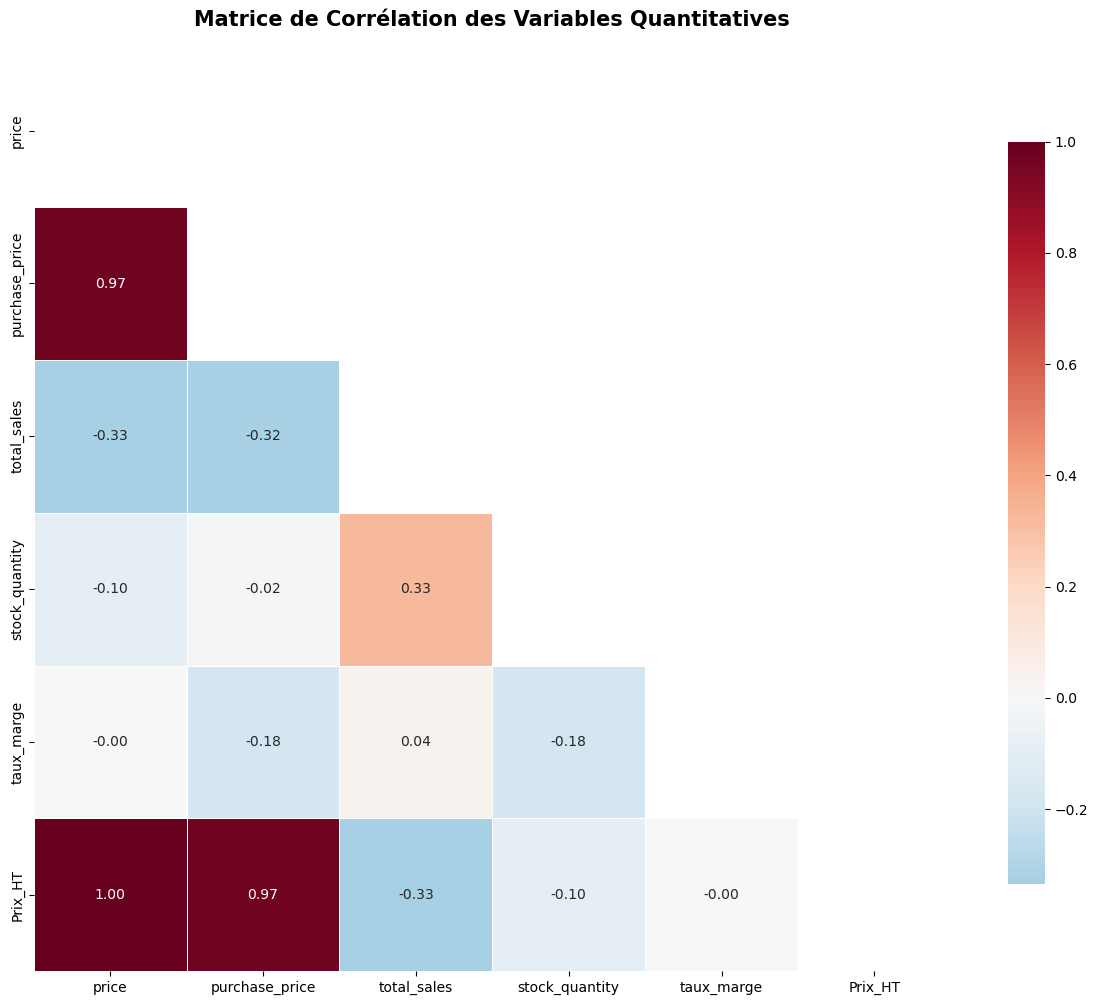

=== Corrélations avec le Chiffre d'Affaires (Total Sales) ===
total_sales       1.000000
stock_quantity    0.326644
taux_marge        0.040800
purchase_price   -0.322033
Prix_HT          -0.334108
price            -0.334108
Name: total_sales, dtype: float64


In [230]:
############################
# Analyse des corrélations #
############################

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# 1. Sélection de TOUTES les variables quantitatives pertinentes
# On ajoute price, purchase_price (coût d'achat) et taux_marge comme demandé
variables_quantitatives = [
    'price', 'purchase_price', 'total_sales', 
    'stock_quantity', 'taux_marge', 'Prix_HT'
]

# Calcul de la matrice sur ce sous-ensemble
df_corr = df_final[variables_quantitatives].corr()

# 2. Configuration du graphique
plt.figure(figsize=(12, 10))

# Masque pour masquer le triangle supérieur (évite la redondance visuelle)
mask = np.triu(np.ones_like(df_corr, dtype=bool))

# 3. Affichage de la heatmap
sns.heatmap(df_corr, 
            mask=mask,
            annot=True, # Affiche les chiffres dans les cases
            fmt=".2f",
            cmap='RdBu_r', # Palette Rouge/Bleu (très lisible pour les corrélations)
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": 0.8})

plt.title('Matrice de Corrélation des Variables Quantitatives', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 4. Affichage des corrélations les plus intéressantes (Optionnel)
print("=== Corrélations avec le Chiffre d'Affaires (Total Sales) ===")
print(df_corr['total_sales'].sort_values(ascending=False))

# 📊 Conclusion de l'analyse des corrélations

L'analyse des corrélations entre les variables clés (stock, ventes web, prix et marge) révèle plusieurs enseignements stratégiques essentiels pour optimiser la gestion commerciale et logistique de l'entreprise.

---

### 🔵 Prix d'achat et prix de vente (corrélation : **0.97**)
Une corrélation très forte est observée entre le prix d'achat (`purchase_price`) et le prix de vente (`price`).

* **Interprétation :** Cette corrélation quasi-parfaite indique que Bottleneck applique une politique de prix rigide basée sur un coefficient multiplicateur constant. Le prix de vente est directement proportionnel au prix d'achat, quelle que soit la catégorie de produit.
* **Implication business :** Cette approche simplifie la gestion tarifaire mais limite la flexibilité stratégique. L'entreprise ne peut pas facilement ajuster ses prix en fonction de la demande ou de la concurrence.

### 🔵 Prix et ventes (corrélation : **-0.33**)
Une corrélation négative modérée est constatée entre le prix de vente et le volume des ventes.

* **Interprétation :** Les produits les plus chers ne se vendent pas nécessairement en plus faible volume. Dans l'univers premium, le prix élevé est souvent perçu comme un signal de qualité. L'élasticité-prix est faible sur ce segment.
* **Implication business :** Marge de manœuvre pour augmenter les prix sur les produits premium (+5 à +10%) sans risquer une chute drastique des volumes, améliorant ainsi la rentabilité globale.

### 🟠 Stock et ventes (corrélation : **0.33**)
Une corrélation positive faible est observée entre le niveau de stock et le volume des ventes.

* **Interprétation :** Révèle un **désalignement** entre stock et demande. Les produits stockés en grande quantité ne sont pas forcément les best-sellers, et inversement.
* **Implication business :** * Immobilisation excessive de capital sur des produits à faible rotation.
    * Perte de CA sur des produits en rupture malgré une forte demande.
* **Action :** Mettre en place un système de gestion prédictive des stocks.

### 🟡 Prix et stock (corrélation : **-0.10**)
Une corrélation quasi nulle entre le prix de vente et le niveau de stock.

* **Interprétation :** La gestion des stocks est indépendante de la rentabilité unitaire. L'entreprise ne privilégie pas le stockage des produits les plus chers.
* **Implication business :** Limite les risques financiers liés au stockage de produits coûteux, mais n'optimise pas la rotation sur les segments à forte marge.

### 🔴 Taux de marge et ventes (corrélation : **0.04**)
Une corrélation nulle entre le taux de marge et le volume des ventes.

* **Interprétation :** Bottleneck ne "sacrifie" pas sa rentabilité pour générer du volume. La marge et le volume évoluent de manière totalement indépendante.
* **Implication business :** Atout stratégique : capacité à développer simultanément du "Luxe" (forte marge/faible volume) et du "Volume" (marge moyenne/fort volume) sans cannibalisation.

### 🔵 Prix d'achat et ventes (corrélation : **-0.32**)
Une corrélation négative modérée.

* **Interprétation :** Confirme que le positionnement "haut de gamme" trouve son marché. Les clients achètent des produits chers en quantités significatives.
* **Implication business :** Valide le développement du catalogue premium (Champagnes millésimés, spiritueux rares) qui génère à la fois volume et marge.

---

### 🎯 Synthèse et recommandations stratégiques

L'analyse confirme que le prix n'est pas le seul moteur des ventes. La gestion des stocks doit cependant être affinée pour mieux coller à la réalité commerciale.

1.  **Flexibiliser la politique de prix :** Sortir du coefficient fixe (0.97) pour adopter un pricing différencié par segment.
2.  **Renforcer la prévision de la demande :** Améliorer la corrélation stock/ventes via des modèles basés sur l'historique.
3.  **Exploiter la faible sensibilité au prix :** Tester des augmentations ciblées sur le segment premium.
4.  **Prioriser les segments rentables :** Focaliser les efforts sur les catégories (Cognac, Whisky) où rentabilité et volume sont décorrélés.
5.  **Optimiser la trésorerie :** Adapter les niveaux de stock selon la vitesse de rotation pour libérer du capital immobilisé.

> **Note pour le CODIR :** Cette approche "data-driven" est essentielle pour aligner nos stocks sur notre ambition de rentabilité tout en garantissant la disponibilité de nos références clés.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [231]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.  
df_final.to_excel("bottleneck_analyse_complete.xlsx", index=False)
print(f"✅ Fichier Excel créé avec succès !")
print(f"📊 Nombre de lignes : {len(df_final)}")
print(f"📋 Nombre de colonnes : {len(df_final.columns)}")

✅ Fichier Excel créé avec succès !
📊 Nombre de lignes : 1539
📋 Nombre de colonnes : 17
